In [1]:
'''
# Multilingual Support Ticket Classification using Traditional ML and Transformer Models

## Goal
Automatically classify customer support tickets into categories (type).

Optional extension:
Predict ticket priority as second task.

## Business Impact
- Faster ticket routing
- Reduced manual sorting
- Improved SLA handling
'''

'\n# Multilingual Support Ticket Classification using Traditional ML and Transformer Models\n\n## Goal\nAutomatically classify customer support tickets into categories (type).\n\nOptional extension:\nPredict ticket priority as second task.\n\n## Business Impact\n- Faster ticket routing\n- Reduced manual sorting\n- Improved SLA handling\n'

In [2]:
'''
FUTURE_ML_02/
│
├── notebooks/
│   ├── 01_data_exploration.ipynb           # Deep EDA + profiling
│   ├── 02_baseline_ml_models.ipynb         # Scikit-learn models (MAIN)
│   ├── 03_huggingface_distilbert.ipynb     # Transformer model (BONUS)
│   └── 04_model_comparison.ipynb           # Final comparison & deployment
│
├── data/
│   ├── raw/
│   │   └── your_dataset.csv                # Your uploaded dataset
│   ├── processed/
│   │   └── cleaned_data.csv                # After preprocessing
│   └── README.md
│
├── models/
│   ├── ml_models/
│   │   ├── tfidf_vectorizer.pkl
│   │   ├── logistic_regression.pkl
│   │   └── best_model.pkl
│   └── transformers/
│       └── distilbert_finetuned/
│
├── reports/
│   ├── figures/
│   │   ├── eda_plots.png
│   │   ├── confusion_matrices.png
│   │   └── model_comparison.png
│   ├── eda_report.html
│   └── performance_metrics.json
│
├── src/
│   ├── preprocessing.py
│   ├── feature_engineering.py
│   └── utils.py
│
├── requirements.txt
└── README.md
'''

'\nFUTURE_ML_02/\n│\n├── notebooks/\n│   ├── 01_data_exploration.ipynb           # Deep EDA + profiling\n│   ├── 02_baseline_ml_models.ipynb         # Scikit-learn models (MAIN)\n│   ├── 03_huggingface_distilbert.ipynb     # Transformer model (BONUS)\n│   └── 04_model_comparison.ipynb           # Final comparison & deployment\n│\n├── data/\n│   ├── raw/\n│   │   └── your_dataset.csv                # Your uploaded dataset\n│   ├── processed/\n│   │   └── cleaned_data.csv                # After preprocessing\n│   └── README.md\n│\n├── models/\n│   ├── ml_models/\n│   │   ├── tfidf_vectorizer.pkl\n│   │   ├── logistic_regression.pkl\n│   │   └── best_model.pkl\n│   └── transformers/\n│       └── distilbert_finetuned/\n│\n├── reports/\n│   ├── figures/\n│   │   ├── eda_plots.png\n│   │   ├── confusion_matrices.png\n│   │   └── model_comparison.png\n│   ├── eda_report.html\n│   └── performance_metrics.json\n│\n├── src/\n│   ├── preprocessing.py\n│   ├── feature_engineering.py\n│   └── utils

*IMPORTING*


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set_context("talk")

In [4]:
df = pd.read_csv('/content/aa_dataset-tickets-multi-lang-5-2-50-version.csv')

*DATASET OVERVIEW*

In [5]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [6]:
df.shape

(28587, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   24749 non-null  object
 1   body      28587 non-null  object
 2   answer    28580 non-null  object
 3   type      28587 non-null  object
 4   queue     28587 non-null  object
 5   priority  28587 non-null  object
 6   language  28587 non-null  object
 7   version   28587 non-null  int64 
 8   tag_1     28587 non-null  object
 9   tag_2     28574 non-null  object
 10  tag_3     28451 non-null  object
 11  tag_4     25529 non-null  object
 12  tag_5     14545 non-null  object
 13  tag_6     5874 non-null   object
 14  tag_7     2040 non-null   object
 15  tag_8     565 non-null    object
dtypes: int64(1), object(15)
memory usage: 3.5+ MB


In [8]:
df.describe()

,version
count,28587.000000
mean,278.382027
std,165.962935
min,51.000000
25%,52.000000
50%,400.000000
75%,400.000000
max,400.000000


*MISSING VALUE ANALYSIS*

In [9]:
df.isnull().sum()

,0
subject,3838
body,0
answer,7
type,0
queue,0
priority,0
language,0
version,0
tag_1,0
tag_2,13


In [10]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": (df.isnull().sum() / len(df)) * 100
}).sort_values("Missing_%", ascending=False)

missing

,Missing_Count,Missing_%
tag_8,28022,98.023577
tag_7,26547,92.863889
tag_6,22713,79.452199
tag_5,14042,49.120229
subject,3838,13.425683
tag_4,3058,10.697170
tag_3,136,0.475741
tag_2,13,0.045475
answer,7,0.024487
language,0,0.000000


In [11]:
df['text'] = df['subject'].fillna('') + " " + df['body'].fillna('')

In [12]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8', 'text'],
      dtype='object')


In [13]:
import re

def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(basic_clean)

In [14]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8', 'text', 'text_clean'],
      dtype='object')

In [15]:
duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print(f"Duplicate Rows: {duplicate_count}")
print(f"Duplicate Percentage: {duplicate_percent:.2f}%")

Duplicate Rows: 0
Duplicate Percentage: 0.00%


*Class Distribution*

In [16]:
type_counts = df['type'].value_counts()
type_percent = df['type'].value_counts(normalize=True) * 100

class_distribution = pd.DataFrame({
    "Count": type_counts,
    "Percentage": type_percent
})

class_distribution

,Count,Percentage
type,,
Incident,11466,40.109141
Request,8187,28.638892
Problem,6012,21.030538
Change,2922,10.221429


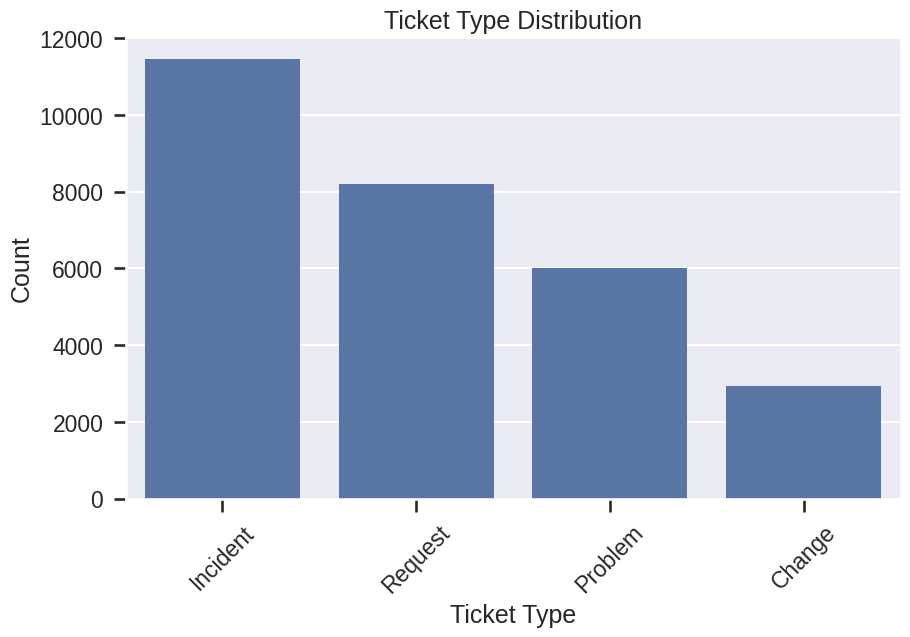

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x=type_counts.index, y=type_counts.values)
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [18]:
imbalance_ratio = type_counts.max() / type_counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

Imbalance Ratio: 3.92


In [19]:
priority_analysis = df['priority'].value_counts(normalize=True) * 100
priority_analysis

,proportion
priority,
medium,40.280547
high,39.101690
low,20.617763


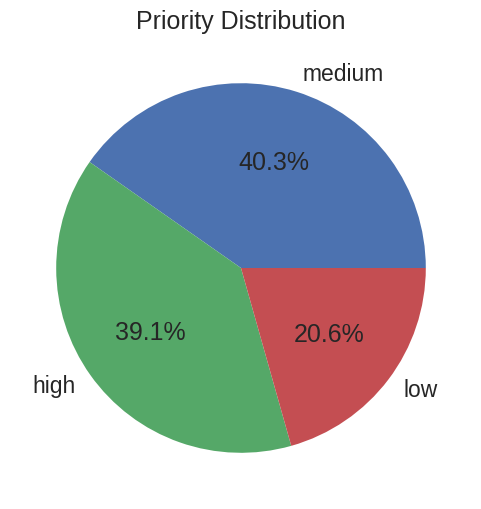

In [20]:
df['priority'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title("Priority Distribution")
plt.ylabel("")
plt.show()

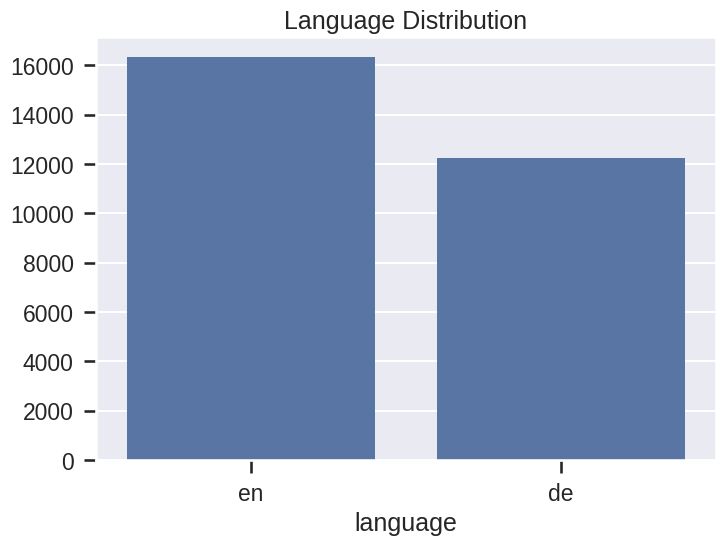

In [21]:
language_counts = df['language'].value_counts()

sns.barplot(x=language_counts.index, y=language_counts.values)
plt.title("Language Distribution")
plt.show()

*Text Length Distribution (Add Real Analysis)*

In [22]:
df['text'] = df['subject'].fillna('') + " " + df['body'].fillna('')
df['char_length'] = df['text'].apply(len)

In [23]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

In [24]:
df[['char_length','word_count']].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

,char_length,word_count
count,28587.000000,28587.000000
mean,426.810019,58.159723
std,200.846416,27.766143
min,14.000000,1.000000
25%,261.000000,35.000000
50%,427.000000,59.000000
75%,588.000000,83.000000
90%,680.000000,92.000000
95%,742.000000,97.000000
99%,844.000000,110.000000


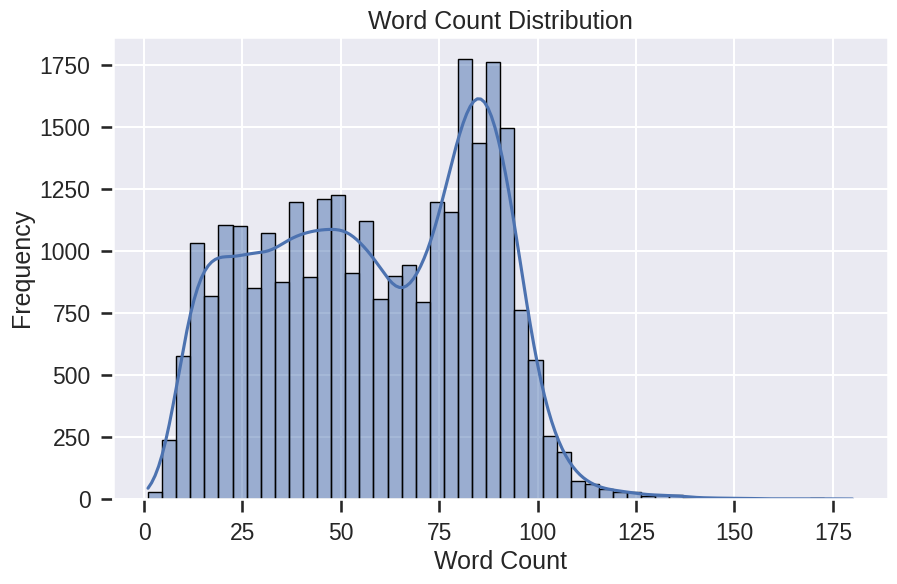

In [25]:
plt.figure(figsize=(10,6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [26]:
print("Word Count Skewness:", df['word_count'].skew())

Word Count Skewness: -0.04526386941565265


In [27]:
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
outliers = df[df['word_count'] > upper_bound]

print(f"Outlier Count: {len(outliers)}")

Outlier Count: 9


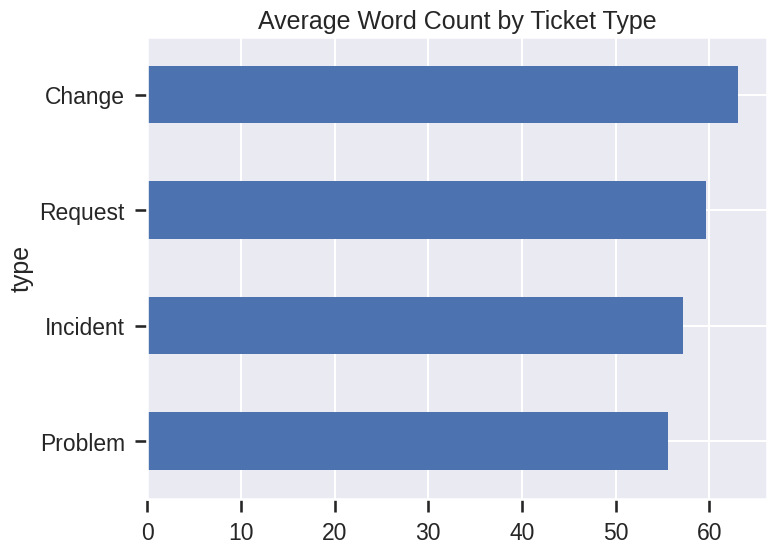

In [28]:
avg_length_by_type = df.groupby('type')['word_count'].mean().sort_values()

avg_length_by_type.plot(kind='barh', figsize=(8,6))
plt.title("Average Word Count by Ticket Type")
plt.show()

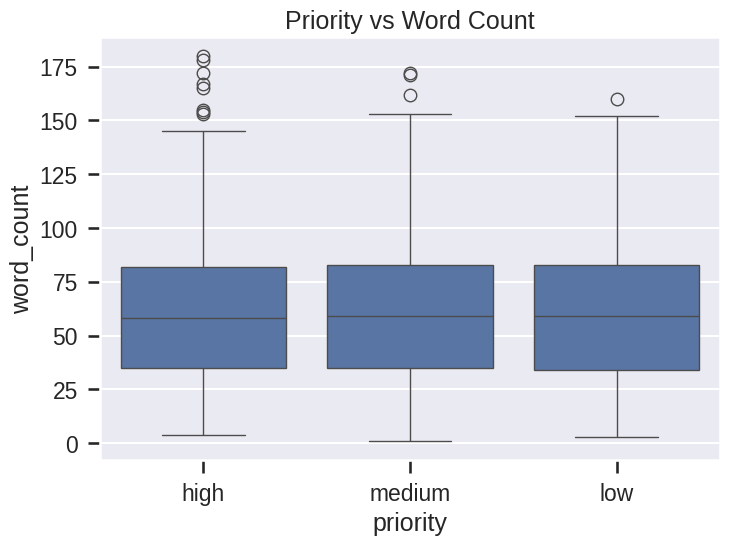

In [29]:
sns.boxplot(x='priority', y='word_count', data=df)
plt.title("Priority vs Word Count")
plt.show()

In [30]:
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Combine English + German stopwords
german_stopwords = set(stopwords.words('german'))
english_stopwords = set(ENGLISH_STOP_WORDS)

all_stopwords = list(english_stopwords.union(german_stopwords))  # <-- FIX

# Create vectorizer
vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    max_features=50
)

X_counts = vectorizer.fit_transform(df['text'])

word_freq = pd.DataFrame({
    "Word": vectorizer.get_feature_names_out(),
    "Frequency": np.asarray(X_counts.sum(axis=0)).flatten()
}).sort_values("Frequency", ascending=False)

word_freq

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Word,Frequency
7,data,16921
43,support,10838
30,problem,10733
20,issue,10209
41,software,9478
18,integration,7810
3,assistance,7603
38,security,6948
6,customer,6752
33,provide,6422


In [31]:
df[['word_count']].corr()

,word_count
word_count,1.0


*Correlation Heatmap*

In [32]:
import numpy as np

# Combine text
df['text'] = df['subject'].fillna('') + " " + df['body'].fillna('')

# Character length
df['char_length'] = df['text'].apply(len)

# Word count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Average word length
df['avg_word_length'] = df['text'].apply(
    lambda x: np.mean([len(word) for word in str(x).split()]) if len(str(x).split()) > 0 else 0
)

# Unique word ratio (lexical diversity)
df['unique_word_ratio'] = df['text'].apply(
    lambda x: len(set(str(x).split())) / len(str(x).split()) if len(str(x).split()) > 0 else 0
)

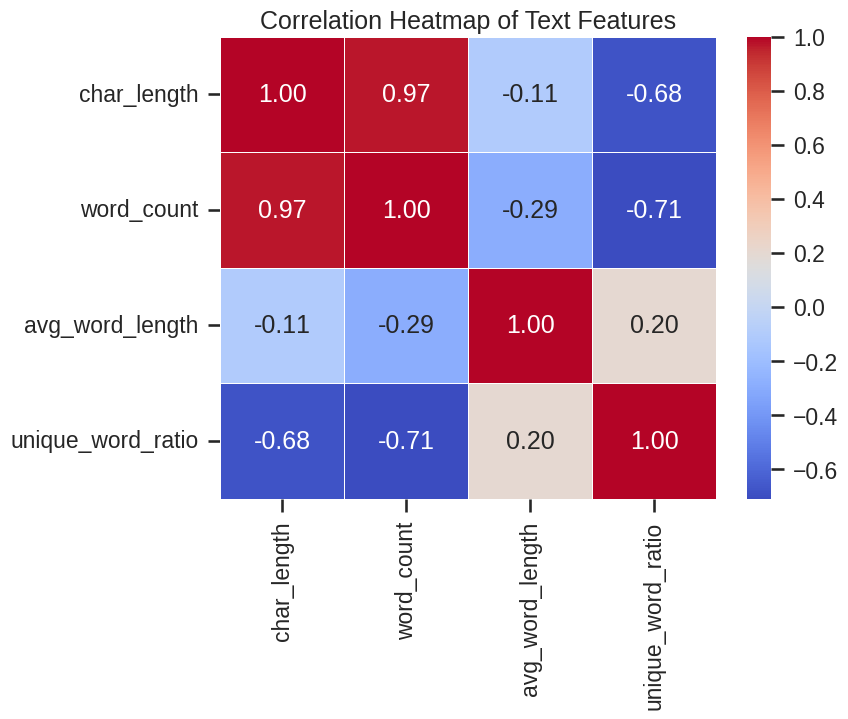

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['char_length', 'word_count', 'avg_word_length', 'unique_word_ratio']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Text Features")
plt.show()

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

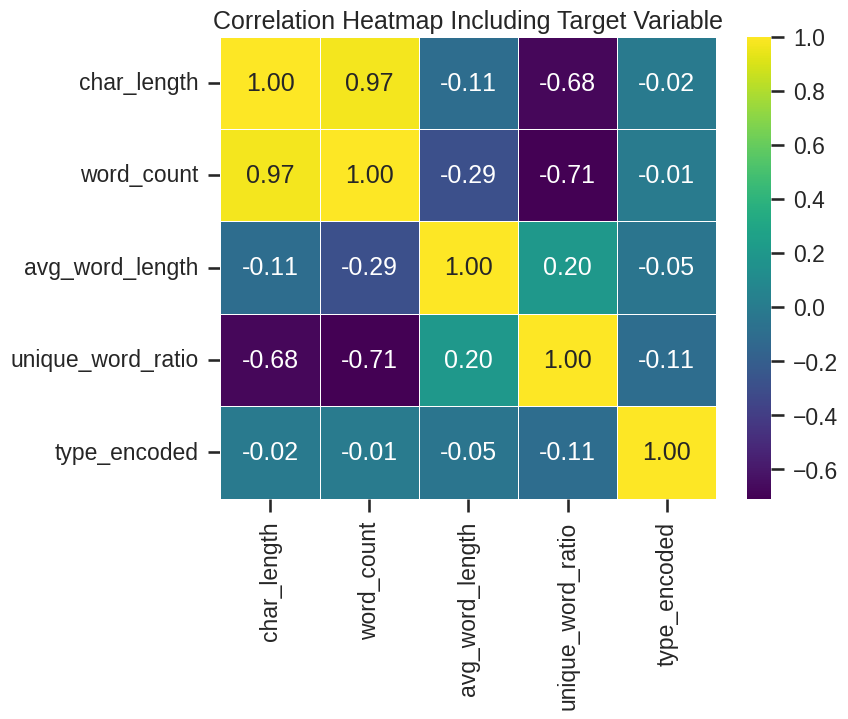

In [35]:
extended_corr = df[numeric_cols + ['type_encoded']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    extended_corr,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap Including Target Variable")
plt.show()

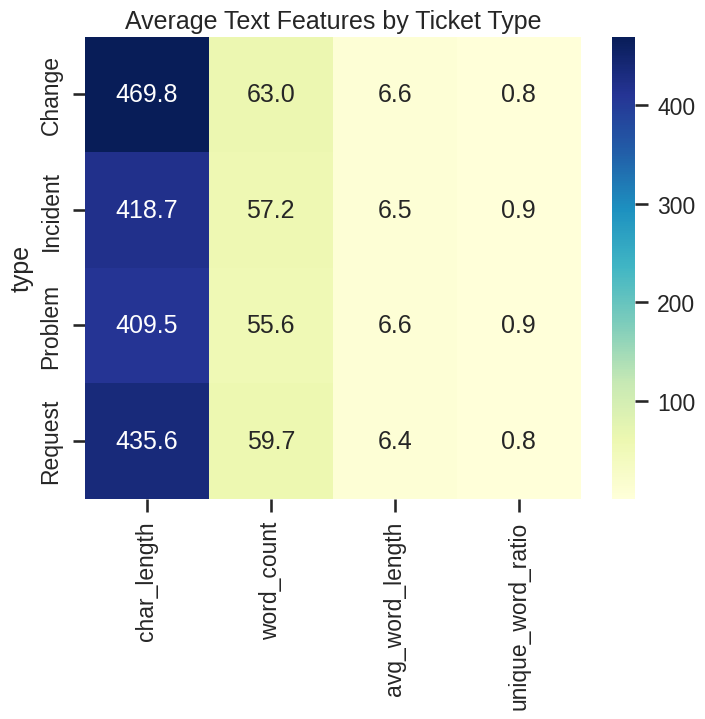

In [36]:
grouped = df.groupby('type')[numeric_cols].mean()

plt.figure(figsize=(8,6))
sns.heatmap(
    grouped,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Average Text Features by Ticket Type")
plt.show()

*Per-Class Word Analysis*

In [37]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_words_per_class(data, label_column, text_column, top_n=15):
    results = {}

    for label in data[label_column].unique():
        subset = data[data[label_column] == label]

        vectorizer = CountVectorizer(
            stop_words='english',
            max_features=2000
        )

        X = vectorizer.fit_transform(subset[text_column])

        word_freq = X.sum(axis=0)
        words = vectorizer.get_feature_names_out()
        frequencies = word_freq.A1

        freq_df = pd.DataFrame({
            "word": words,
            "frequency": frequencies
        }).sort_values(by="frequency", ascending=False)

        results[label] = freq_df.head(top_n)

    return results

In [38]:
top_words = get_top_words_per_class(df, "type", "text_clean", top_n=15)

In [39]:
combined = pd.DataFrame()

for label, freq_df in top_words.items():
    temp = freq_df.set_index("word")["frequency"]
    combined[label] = temp

combined = combined.fillna(0)

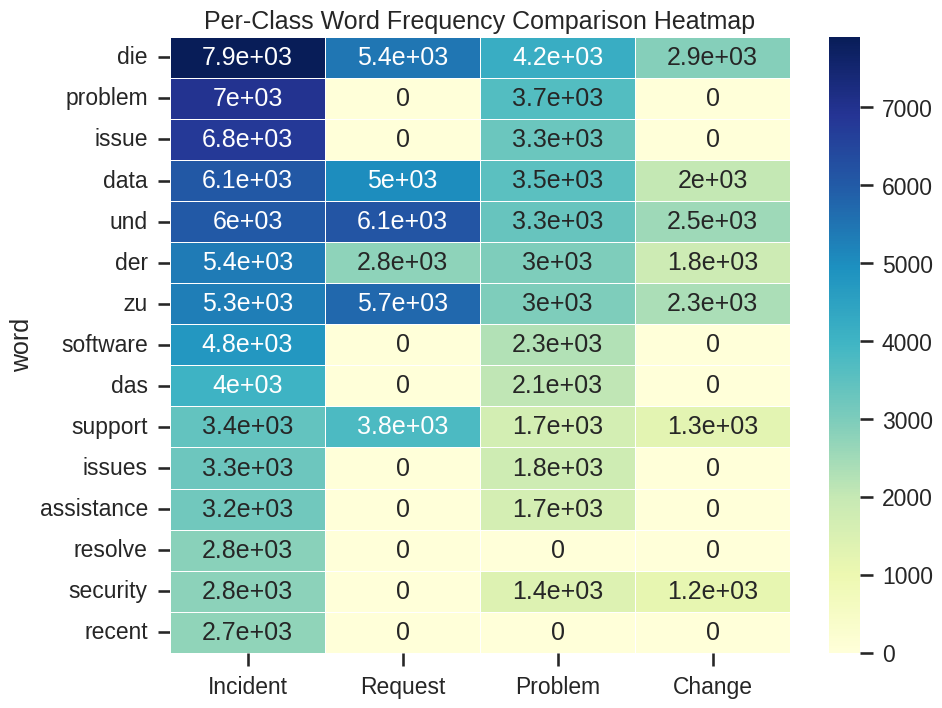

In [40]:
plt.figure(figsize=(10,8))
sns.heatmap(
    combined,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Per-Class Word Frequency Comparison Heatmap")
plt.show()

In [41]:
'''
## Key Insights for Modeling

1. Dataset shows moderate class imbalance (Imbalance Ratio: X).
2. Text distribution is right-skewed with long-tail behavior.
3. Some extreme-length outliers detected.
4. Bilingual dataset requires language strategy decision.
5. Word frequency suggests domain-specific vocabulary (e.g., refund, login, system).
6. Average word count varies across ticket types, indicating possible predictive signal.
'''

'\n## Key Insights for Modeling\n\n1. Dataset shows moderate class imbalance (Imbalance Ratio: X).\n2. Text distribution is right-skewed with long-tail behavior.\n3. Some extreme-length outliers detected.\n4. Bilingual dataset requires language strategy decision.\n5. Word frequency suggests domain-specific vocabulary (e.g., refund, login, system).\n6. Average word count varies across ticket types, indicating possible predictive signal.\n'

In [42]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8', 'text', 'text_clean', 'char_length', 'word_count',
       'avg_word_length', 'unique_word_ratio', 'type_encoded'],
      dtype='object')

In [45]:
df.to_csv("cleaned_data.csv", index=False)

In [46]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8', 'text', 'text_clean', 'char_length', 'word_count',
       'avg_word_length', 'unique_word_ratio', 'type_encoded'],
      dtype='object')

In [48]:
df.shape

(28587, 23)

In [49]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_6,tag_7,tag_8,text,text_clean,char_length,word_count,avg_word_length,unique_word_ratio,type_encoded
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,...,NaN,NaN,NaN,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...,wesentlicher sicherheitsvorfall sehr geehrtes ...,783,84,8.333333,0.869048,1
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,...,NaN,NaN,NaN,"Account Disruption Dear Customer Support Team,...",account disruption dear customer support teamn...,563,84,5.714286,0.833333,1
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,...,NaN,NaN,NaN,Query About Smart Home System Integration Feat...,query about smart home system integration feat...,585,83,6.060241,0.819277,3
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,...,NaN,NaN,NaN,Inquiry Regarding Invoice Details Dear Custome...,inquiry regarding invoice details dear custome...,639,95,5.736842,0.768421,3
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,...,NaN,NaN,NaN,Question About Marketing Agency Software Compa...,question about marketing agency software compa...,732,103,6.116505,0.776699,2


In [50]:
processed_df = df[
    [
        "text",
        "type",
        "type_encoded",
        "char_length",
        "word_count",
        "avg_word_length",
        "unique_word_ratio"
    ]
]

processed_df.to_csv("cleaned_data.csv", index=False)

In [53]:
df_check = pd.read_csv("cleaned_data.csv")
df_check.columns

Index(['text', 'type', 'type_encoded', 'char_length', 'word_count',
       'avg_word_length', 'unique_word_ratio'],
      dtype='object')

In [55]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>